In [2]:
#pip install tensorflow


In [3]:
#pip install pandas numpy matplotlib scikit-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
# 1. Load dữ liệu
df = pd.read_csv("../../data/processed/training_data_final.csv", parse_dates=["Datetime"], index_col="Datetime")

# Chọn cột GOLD để dự đoán
data = df[["Gold"]]

In [6]:
# 2. Tiền xử lí dữ liệu
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [7]:
# 3. Tạo tập dữ liệu huấn luyện và kiểm tra
X, y = [], []
window = 60  # 60 phút trước

for i in range(window, len(scaled_data)):
    X.append(scaled_data[i-window:i, 0])  
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)


In [8]:
# 4.Reshape dữ liệu cho LSTM (3D)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
# Chia train/test theo thời gian
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [9]:
# 5.Xây dựng mô hình LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')


c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# 6. Huấn luyện mô hình
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 390s 95ms/step - loss: 3.3302e-05 - val_loss: 5.7306e-07
Epoch 2/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 419s 104ms/step - loss: 2.2507e-06 - val_loss: 1.7765e-05
Epoch 3/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 339s 78ms/step - loss: 1.4201e-06 - val_loss: 2.4662e-08
Epoch 4/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 386s 94ms/step - loss: 1.1373e-06 - val_loss: 1.9645e-08
Epoch 5/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 336s 82ms/step - loss: 8.5643e-07 - val_loss: 8.5959e-09
Epoch 6/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 442s 97ms/step - loss: 8.1726e-07 - val_loss: 1.5912e-09
Epoch 7/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 405s 88ms/step - loss: 7.2906e-07 - val_loss: 2.4005e-09
Epoch 8/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 381s 87ms/step - loss: 6.7450e-07 - val_loss: 4.9893e-08
Epoch 9/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 374s 94ms/step - loss: 6.5717e-07 - val_loss: 3.1656e-10
Epoch 10/20
4001/4001 ━━━━━━━━━━━━━━━━━━━━ 245s 59ms/step - loss: 5.9034e-07 - val_loss: 1.2013e-09
Epoch 11

In [11]:
# 7. Dự đoán
y_pred_scaled = model.predict(X_test)

# Chuyển từ [0,1] về giá thật
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))


1112/1112 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step


In [12]:
# 8. Đánh giá mô hình
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print("RMSE:", rmse)
print("R² score:", r2)


RMSE: 3.0221918270537484
R² score: 0.9974322745991175


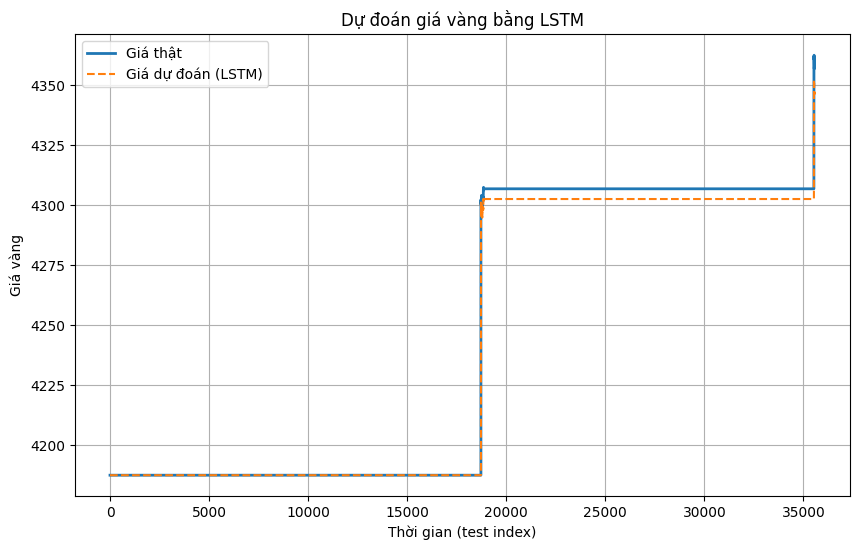

In [13]:
# 9. Vẽ biểu đồ dự đoán
plt.figure(figsize=(10,6))
plt.plot(y_test_real, label="Giá thật", linewidth=2)
plt.plot(y_pred, label="Giá dự đoán (LSTM)", linestyle='--')
plt.title("Dự đoán giá vàng bằng LSTM")
plt.xlabel("Thời gian (test index)")
plt.ylabel("Giá vàng")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os

# 1. Load data gốc (để lấy thông tin min/max của giá Vàng thật)
# Bạn sửa lại đường dẫn đúng tới file data sạch của bạn
path_data = '../../data/raw/data_price_realtime.csv' # Hoặc file data_final của bạn
df_raw = pd.read_csv(path_data, parse_dates=['Datetime'], index_col='Datetime')

# 2. Tạo một Scaler riêng chỉ cho cột Gold (Target)
# Việc này giúp việc inverse_transform không bị lỗi kích thước
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(df_raw[['Gold']]) # Học min/max của cột Gold

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [18]:
# 4. Xử lý thời gian (Fix lỗi AttributeError bạn gặp lúc nãy)
# Lấy n dòng cuối cùng của index gốc, với n = số lượng mẫu dự đoán
test_dates = df_raw.index[-len(pred_usd):]

# 5. Tạo DataFrame
result_df = pd.DataFrame({
    'Datetime': test_dates,
    'Actual': y_test_real.flatten(),
    'Predicted': y_pred.flatten()
})

# 6. Lưu file CSV
save_path = '../../results/predictions/LSTM.csv'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
result_df.to_csv(save_path, index=False)

print(f"✅ Đã lưu kết quả LSTM (USD) vào: {save_path}")
print(result_df.head())

✅ Đã lưu kết quả LSTM (USD) vào: ../../results/predictions/LSTM.csv
             Datetime   Actual    Predicted
0 2025-12-08 22:58:27  4187.47  4187.462402
1 2025-12-08 22:58:27  4187.47  4187.462402
2 2025-12-08 22:58:27  4187.47  4187.462402
3 2025-12-08 22:58:27  4187.47  4187.462402
4 2025-12-08 22:58:27  4187.47  4187.462402
